In [21]:
import yfinance as yf
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt

[*********************100%***********************]  3 of 3 completed


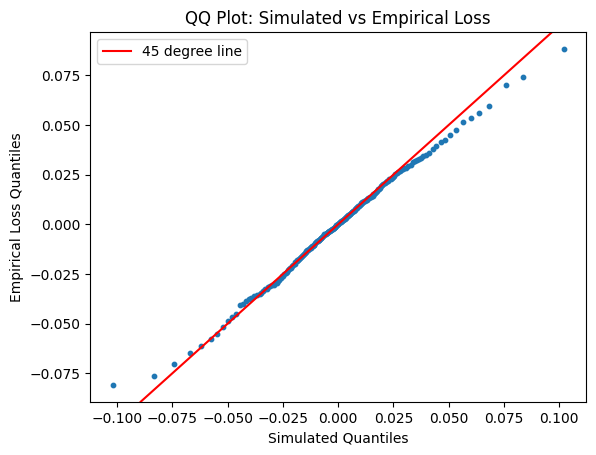

    Data Type   95% VaR
0   Empirical  0.042666
1  Parametric  0.047758
2   Simulated  0.048343
    Data Type  95% CVaR
0   Empirical  0.065488
1  Parametric  0.071855
2   Simulated  0.071932
Predicted loss in the next 21 trading days at a 95% level is 15.06930122352424%


In [75]:
tickers = ['AUB.AX', 'TLX.AX', 'PLY.AX']
weights = {'AUB.AX': 0.1, 'TLX.AX': 0.4, 'PLY.AX': 0.5}
data = yf.download(tickers, period='5y', interval='1d')['Close']
daily_log_returns = np.log(data/data.shift(1)).dropna()
daily_log_returns.columns = tickers
loss_vector = pd.Series()
weighted_returns = pd.DataFrame()
for stock in tickers:
    weighted_returns[stock] = daily_log_returns[stock]*weights[stock]

weighted_returns.index = daily_log_returns.index

for day in daily_log_returns.index:
    loss_vector.loc[day] = (weighted_returns.loc[day].sum())*-1

loss_vector.index = daily_log_returns.index

df, location_param, scale_param = ss.t.fit(loss_vector)

df_fit = df*0.80

mean_loss = loss_vector.mean()
sd_loss = loss_vector.std()
simulation = ss.t.rvs(df=df_fit, loc=location_param, scale=scale_param, size=10000)

quantiles = np.arange(0.005, 1, 0.005)  

loss_quantiles = np.quantile(loss_vector, quantiles)
sim_quantiles = np.quantile(simulation, quantiles)

plt.scatter(sim_quantiles, loss_quantiles, s=10)
plt.axline((0,0), slope=1, label='45 degree line', color='red')
plt.xlabel('Simulated Quantiles')
plt.ylabel('Empirical Loss Quantiles')
plt.title('QQ Plot: Simulated vs Empirical Loss')
plt.legend()
plt.show()

VaR_para = ss.t.ppf(0.95, df_fit, location_param, scale_param) 
VaR_emp = np.quantile(loss_vector, 0.95)
VaR_sim = np.quantile(simulation, 0.95) 

VaR_table = pd.DataFrame({'Data Type': ['Empirical', 'Parametric', 'Simulated'],
                          '95% VaR': [VaR_emp, VaR_para, VaR_sim]})

print(VaR_table)

CVaR_para = ss.t.expect(func= lambda x:x, args=(df_fit,), loc=location_param, scale=scale_param, lb=VaR_para, conditional=True)
CVaR_emp = loss_vector[loss_vector > VaR_emp].mean()
CVaR_sim = simulation[simulation > VaR_sim].mean()

CVaR_table = pd.DataFrame({'Data Type': ['Empirical', 'Parametric', 'Simulated'],
                          '95% CVaR': [CVaR_emp, CVaR_para, CVaR_sim]})

print(CVaR_table)

last_loss = loss_vector.iloc[-1]
predicted_loss = ss.norm.ppf(0.95, loc=last_loss+(location_param)*21, scale=scale_param * (21**0.5))

print(f"Predicted loss in the next 21 trading days at a 95% level is {str(predicted_loss*100)}%")



In [84]:
def loss_predictor(tickers, weights, horizon, percentile):
    data = yf.download(tickers, period='5y', interval='1d')['Close']
    daily_log_returns = np.log(data/data.shift(1)).dropna()
    daily_log_returns.columns = tickers
    loss_vector = pd.Series()
    weighted_returns = pd.DataFrame()
    for stock in tickers:
        weighted_returns[stock] = daily_log_returns[stock]*weights[stock]

    weighted_returns.index = daily_log_returns.index

    for day in daily_log_returns.index:
        loss_vector.loc[day] = (weighted_returns.loc[day].sum()) * -1

    loss_vector.index = daily_log_returns.index

    df, location_param, scale_param = ss.t.fit(loss_vector)

    df_fit = df*0.80

    mean_loss = loss_vector.mean()
    sd_loss = loss_vector.std()
    simulation = ss.t.rvs(df=df_fit, loc=location_param, scale=scale_param, size=10000)

    quantiles = np.arange(0.005, 1, 0.005)  

    loss_quantiles = np.quantile(loss_vector, quantiles)
    sim_quantiles = np.quantile(simulation, quantiles)

    plt.scatter(sim_quantiles, loss_quantiles, s=10)
    plt.axline((0,0), slope=1, label='45 degree line', color='red')
    plt.xlabel('Simulated Quantiles')
    plt.ylabel('Empirical Loss Quantiles')
    plt.title('QQ Plot: Simulated vs Empirical Loss')
    plt.legend()
    plt.show()

    VaR_para = ss.t.ppf(percentile, df_fit, location_param, scale_param) 
    VaR_emp = np.quantile(loss_vector, percentile)
    VaR_sim = np.quantile(simulation, percentile) 

    VaR_table = pd.DataFrame({'Data Type': ['Empirical', 'Parametric', 'Simulated'],
                            f'{percentile*100:.0f}% VaR': [VaR_emp, VaR_para, VaR_sim]})

    print("\n")
    print(f"Next day loss VaR:")
    print(VaR_table)

    CVaR_para = ss.t.expect(func= lambda x:x, args=(df_fit,), loc=location_param, scale=scale_param, lb=VaR_para, conditional=True)
    CVaR_emp = loss_vector[loss_vector > VaR_emp].mean()
    CVaR_sim = simulation[simulation > VaR_sim].mean()

    CVaR_table = pd.DataFrame({'Data Type': ['Empirical', 'Parametric', 'Simulated'],
                            f'{percentile*100:.0f}% CVaR': [CVaR_emp, CVaR_para, CVaR_sim]})

    print("\n")
    print(f"Next day loss CVaR:")
    print(CVaR_table)

    last_loss = loss_vector.iloc[-1]
    predicted_loss = ss.norm.ppf(percentile, loc=last_loss+(location_param)*horizon, scale=scale_param * (horizon**0.5))

    print("\n")
    print(f"Predicted loss in the next {horizon} trading days at a {percentile*100:.0f}% level is {str(predicted_loss*100)}%")